In [1]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1)	A partir da imagem original obtenha as outras imagens conforme descrição

Desejamos separar linhas de círculos. Uma operação de abertura com um elemento estruturante na forma de círculo (definir o raio) faz essa tarefa. Gere uma imagem com os círculos e uma com as linhas


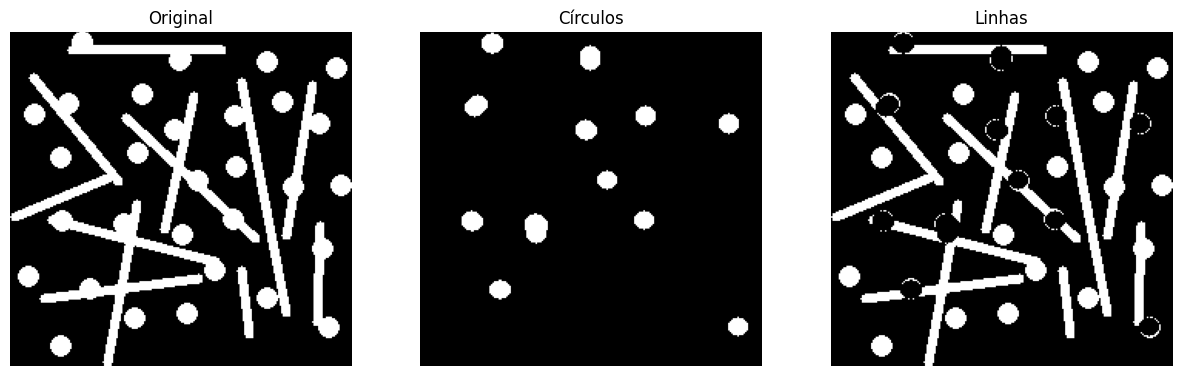

In [17]:

img = cv2.imread("art3.png", cv2.IMREAD_GRAYSCALE)

_, binaria = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

raio = 6   # 5,7,8

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (2*raio+1, 2*raio+1)
)

circulos = cv2.morphologyEx(
    binaria,
    cv2.MORPH_OPEN,
    kernel
)

linhas = cv2.subtract(binaria, circulos)
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(binaria, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(circulos, cmap='gray')
plt.title("Círculos")
plt.axis("off")

plt.subplot(133)
plt.imshow(linhas, cmap='gray')
plt.title("Linhas")
plt.axis("off")

plt.show()

2)

a) Obter linhas verticais. Abertura com elemento estruturante vertical 3x9
b) Obter linhas horizontais. Abertura com elemento estruturante horizontal 9x3. Tente eliminar as linhas erradas usando uma máscara maior


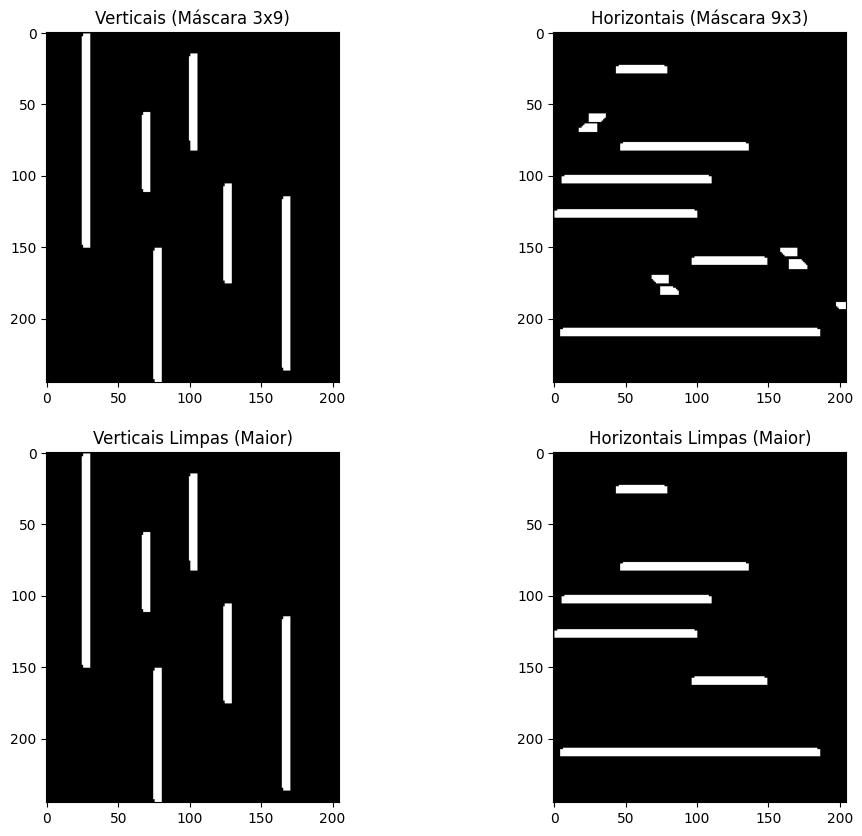

In [3]:
img2 = cv2.imread("art2.png", cv2.IMREAD_GRAYSCALE)


kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 9))
kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3))

linhas_v = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_v)
linhas_h = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_h)

kernel_v_maior = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 25))
kernel_h_maior = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 3))

linhas_v_limpas = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_v_maior)
linhas_h_limpas = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_h_maior)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(linhas_v, cmap='gray'); axes[0, 0].set_title('Verticais (Máscara 3x9)')
axes[0, 1].imshow(linhas_h, cmap='gray'); axes[0, 1].set_title('Horizontais (Máscara 9x3)')
axes[1, 0].imshow(linhas_v_limpas, cmap='gray'); axes[1, 0].set_title('Verticais Limpas (Maior)')
axes[1, 1].imshow(linhas_h_limpas, cmap='gray'); axes[1, 1].set_title('Horizontais Limpas (Maior)')
plt.show()

3)

a) Theshold (t=210)

b) Utilizando abertura com elemento circular de 11 pixels para reter as células grandes

c) É possível reter somente os objetos pequenos utilizando a operação abertura?

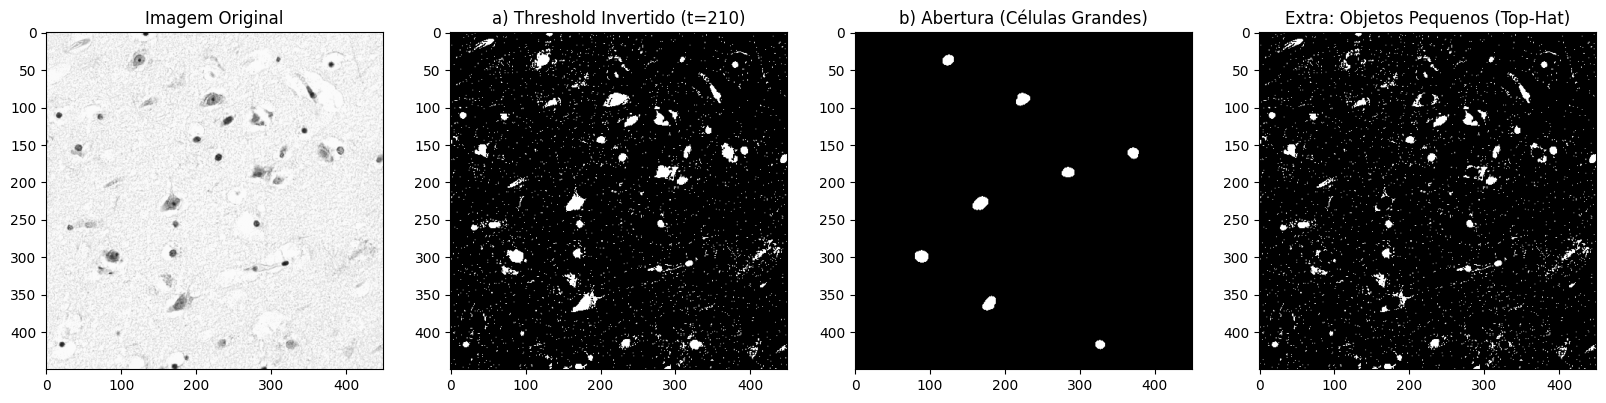

In [ ]:
img3 = cv2.imread("cel4.png", cv2.IMREAD_GRAYSCALE)

_, img_bin = cv2.threshold(img3, 210, 255, cv2.THRESH_BINARY_INV)

kernel_circular = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))


celulas_grandes = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel_circular)

objetos_pequenos = cv2.subtract(img_bin, celulas_grandes)


fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img3, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem Original')

axes[1].imshow(img_bin, cmap='gray')
axes[1].set_title('a) Threshold Invertido (t=210)')

axes[2].imshow(celulas_grandes, cmap='gray')
axes[2].set_title('b) Abertura (Células Grandes)')

axes[3].imshow(objetos_pequenos, cmap='gray')
axes[3].set_title('Extra: Objetos Pequenos (Top-Hat)')

plt.show()

4)
Utilizando os conceitos já aprendidos na disciplina, faça um código que calcula a quantidade de objetos da imagem abaixo. Pode-se utilizar funções prontas do opencv (não para realizar a contagem em si, mas para realizar os passos necessários)

Quantidade estimada de feijões: 461


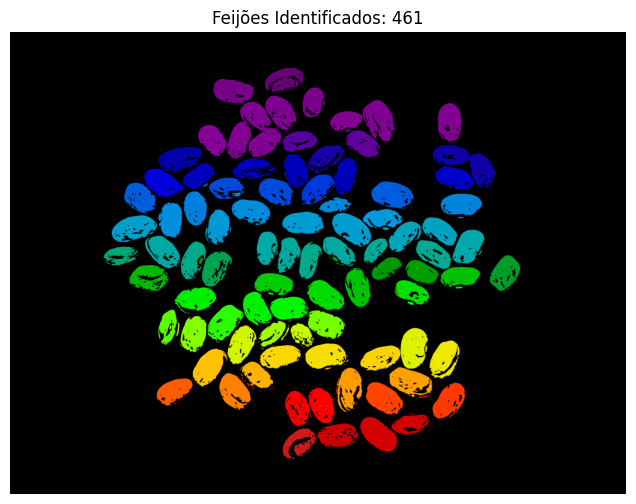

In [ ]:


img4 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

_, img_bin = cv2.threshold(img4, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
img_limpa = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)

num_labels, labels = cv2.connectedComponents(img_limpa)
qtd_feijoes = num_labels - 1

print(f"Quantidade estimada de feijões: {qtd_feijoes}")

plt.figure(figsize=(8,6))
plt.imshow(labels, cmap='nipy_spectral')
plt.title(f'Feijões Identificados: {qtd_feijoes}')
plt.axis('off')
plt.show()


5.  Utilize a transformada hit or miss para localizar o logotipo da UFU. Escolha um deles

Ocorrências encontradas: 1


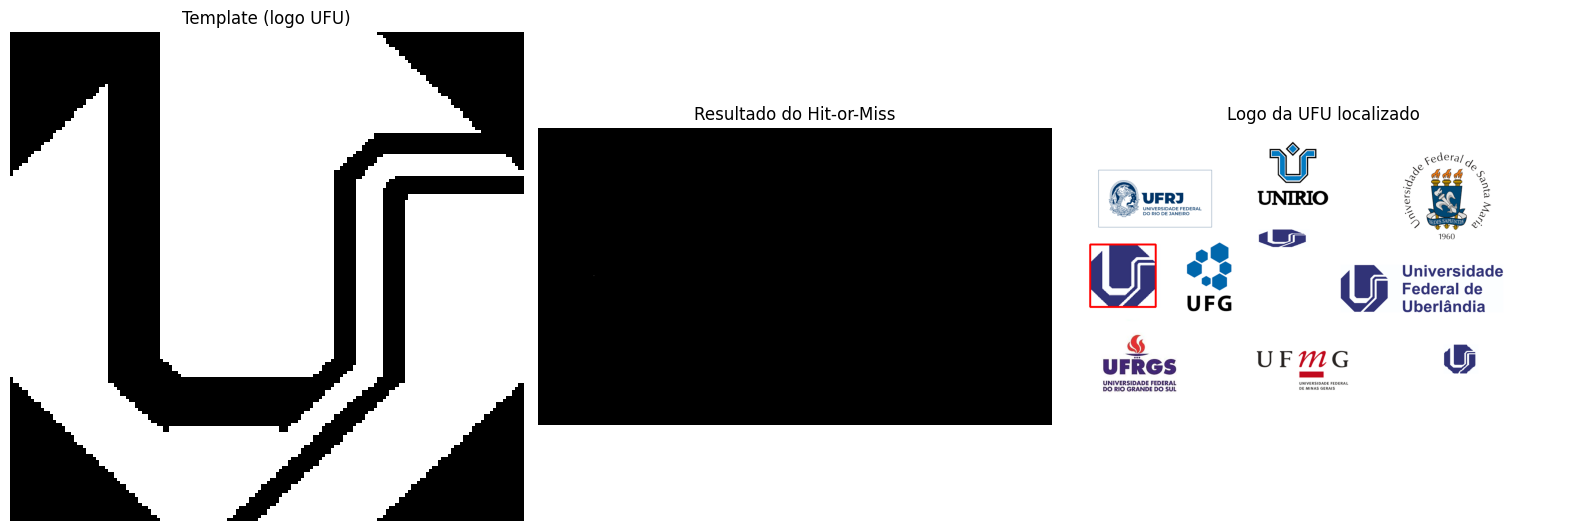

In [16]:


img_gray  = cv2.imread("logotipos.png", cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread("logotipos.png")

_, img_bin = cv2.threshold(img_gray, 200, 1, cv2.THRESH_BINARY_INV)

y0, y1, x0, x1 = 298, 458, 59, 227
template = img_bin[y0:y1, x0:x1]

kernel = np.where(template == 1, 1, -1).astype(np.int8)

hitmiss = cv2.morphologyEx(img_bin, cv2.MORPH_HITMISS, kernel)

ys, xs = np.where(hitmiss > 0)
print(f"Ocorrências encontradas: {len(ys)}")

kh, kw = kernel.shape
img_result = img_color.copy()
for (cy, cx) in zip(ys, xs):
    top_left = (cx - kw // 2, cy - kh // 2)
    bottom_right = (top_left[0] + kw, top_left[1] + kh)
    cv2.rectangle(img_result, top_left, bottom_right, (0, 0, 255), 4)


fig, axs = plt.subplots(1, 3, figsize=(16, 6))

axs[0].imshow(template, cmap="gray")
axs[0].set_title("Template (logo UFU)")
axs[0].axis("off")

axs[1].imshow(hitmiss, cmap="gray")
axs[1].set_title("Resultado do Hit-or-Miss")
axs[1].axis("off")

axs[2].imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
axs[2].set_title("Logo da UFU localizado")
axs[2].axis("off")

plt.tight_layout()
plt.savefig("resultado_hitmiss.png", dpi=150)
plt.show()

6. Utilize operadores morfológicos para extração de fronteiras dos feijões. Mostre o resultado junto com a imagem original

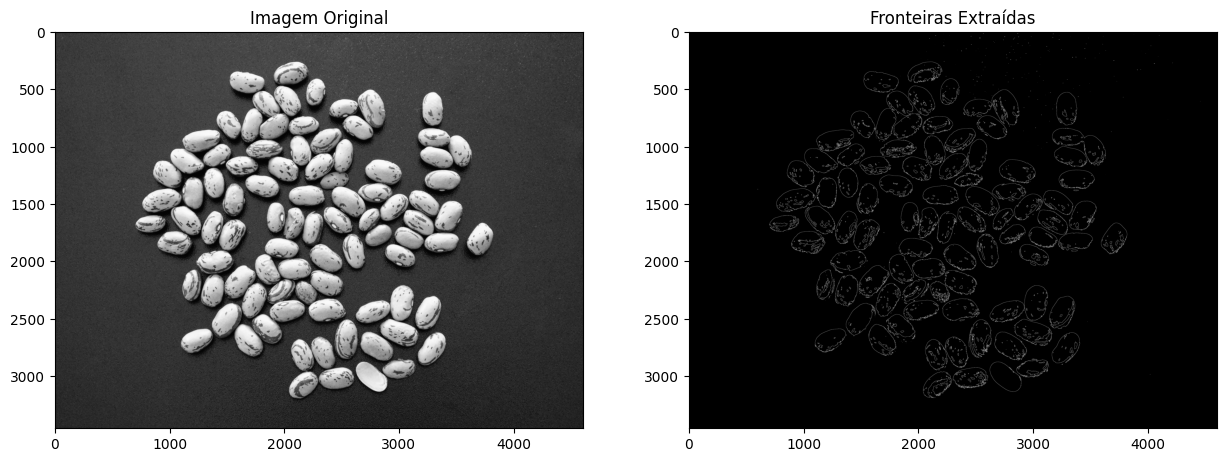

In [10]:
img_feijoes = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

_, img_bin_feijao = cv2.threshold(img_feijoes, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel_borda = np.ones((3,3), np.uint8)

img_erodida = cv2.erode(img_bin_feijao, kernel_borda, iterations=1)

fronteira = cv2.subtract(img_bin_feijao, img_erodida)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(img_feijoes, cmap='gray')
axes[0].set_title('Imagem Original')

axes[1].imshow(fronteira, cmap='gray')
axes[1].set_title('Fronteiras Extraídas')
plt.show()